In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import scipy.stats as stats

In [3]:
#get data
jordan = pd.read_csv('data/jordan-river.csv')
bear = pd.read_csv('data/bear-river.csv')
weber = pd.read_csv('data/weber-river.csv')

cols_to_drop = [
    'x', 'y', 'id', 'time_series_id', 'monitoring_location_id',
    'parameter_code', 'statistic_id',
    'approval_status', 'qualifier', 'last_modified'
]

for river in [jordan, bear, weber]:
    river['time'] = pd.to_datetime(river['time'])
    river.drop(cols_to_drop, axis=1, inplace=True)
    river.sort_values('time', inplace=True)
    river['days'] = (river['time'] - river['time'].min()).dt.days
#combine
df = jordan.merge(bear, on="time", how="outer")
df = df.merge(weber, on="time", how="outer")
df['value'] = df['value'] + df['value_x'] + df['value_y']
df['value'] = df['value'] * 0.0283168 #conversion to cubic meters
print(df.head())
df.drop(['unit_of_measure_x', 'unit_of_measure_y', 'value_x', 'value_y', 'days_x', 'days_y'], axis=1, inplace=True)
df.drop('unit_of_measure', axis=1, inplace=True)

        time  value_x unit_of_measure_x  days_x  value_y unit_of_measure_y  \
0 1998-10-24    144.0            ft^3/s       0   2080.0            ft^3/s   
1 1998-10-25    143.0            ft^3/s       1   2090.0            ft^3/s   
2 1998-10-26    156.0            ft^3/s       2   2590.0            ft^3/s   
3 1998-10-27    165.0            ft^3/s       3   2270.0            ft^3/s   
4 1998-10-28    161.0            ft^3/s       4   2430.0            ft^3/s   

   days_y      value unit_of_measure  days  
0       0  73.567046          ft^3/s     0  
1       1  74.076749          ft^3/s     1  
2       2  88.744851          ft^3/s     2  
3       3  79.768426          ft^3/s     3  
4       4  83.194758          ft^3/s     4  


In [4]:
df.to_csv("data/historical_river_inflow.csv")

In [5]:
#fit sinusoidal wave
x = df["days"].to_numpy()
y = df["value"].to_numpy()

def sinusoid(t, A, B, phi, C):
    return A * np.sin(B * t + phi) + C

A0 = (y.max() - y.min()) / 2
B0 = 2 * np.pi / 365.25
phi0 = 0
C0 = y.mean()

params, _ = curve_fit(sinusoid, x, y, p0=[A0, B0, phi0, C0])
A_fit, B_fit, phi_fit, C_fit = params

df["fit"] = sinusoid(df["days"], A_fit, B_fit, phi_fit, C_fit)



In [6]:
df.head()

,time,value,days,fit
0,1998-10-24,73.567046,0,20.391395
1,1998-10-25,74.076749,1,20.640754
2,1998-10-26,88.744851,2,20.897452
3,1998-10-27,79.768426,3,21.161411
4,1998-10-28,83.194758,4,21.432555


In [7]:
#fit attempt 2
def seasonal_two_harmonics(t, A1, phi1, A2, phi2, C):
    omega = 2 * np.pi / 365
    return (
        A1 * np.sin(omega * t + phi1)
        + A2 * np.sin(2 * omega * t + phi2)
        + C
    )

p0 = [
    (y.max() - y.min()) / 2, 0,
    (y.max() - y.min()) / 4, 0,
    y.mean()
]

params2, _ = curve_fit(seasonal_two_harmonics, x, y)
print(params2)
df["fit2"] = seasonal_two_harmonics(df["days"], *params2)

[-28.97393599 -23.20200893 -18.43745938   4.2925041   45.52330359]


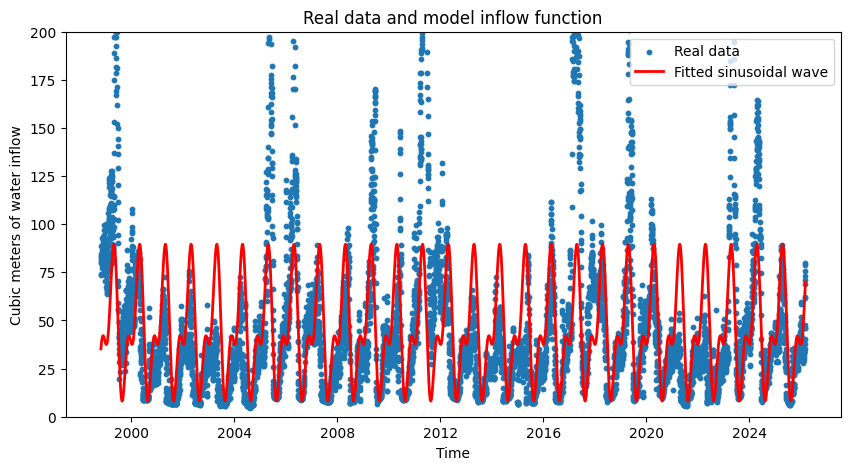

In [8]:
plt.figure(figsize=(10, 5))
plt.scatter(df["time"], df["value"], s=10, label="Real data")
plt.plot(df["time"], df["fit2"], linewidth=2, label="Fitted sinusoidal wave", c='r')
plt.title(r"Real data and model inflow function")
plt.xlabel("Time")
plt.ylabel("Cubic meters of water inflow")
plt.legend()
plt.ylim(0, 200)
plt.savefig('images/basic_inflow_1.png')
plt.show()

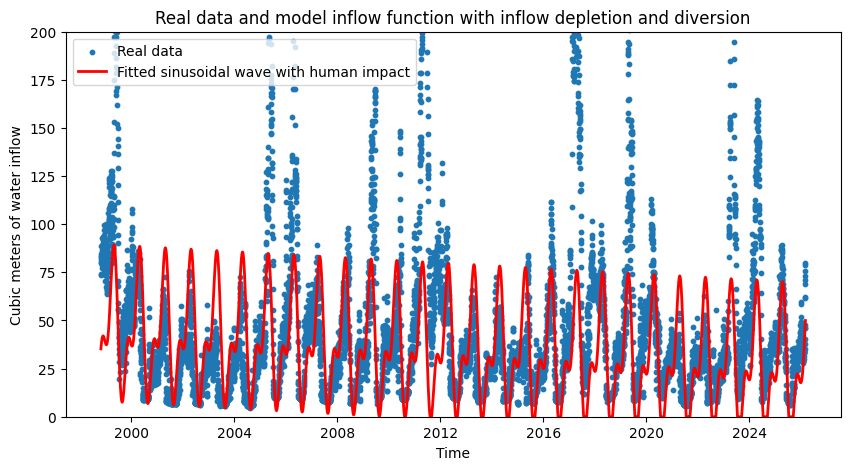

In [453]:
#to account for human impact, add a negative linear trend
seasonal_two_harmonics_human = lambda t, A1, phi1, A2, phi2, C, nu: (
    A1 * np.sin(2 * np.pi / 365 * t + phi1)
    + A2 * np.sin(2 * 2 * np.pi / 365 * t + phi2)
    + C
)   - (nu * t)

df['fit3'] = seasonal_two_harmonics_human(df["days"], *params2,  0.002)
plt.figure(figsize=(10, 5))
plt.scatter(df["time"], df["value"], s=10, label="Real data")
plt.plot(df["time"], np.maximum(df["fit3"], 0), linewidth=2, label="Fitted sinusoidal wave with human impact", c='r')
plt.title(r"Real data and model inflow function with inflow depletion and diversion")
plt.ylim(0, 200)
plt.xlabel("Time")
plt.ylabel("Cubic meters of water inflow")
plt.legend()
plt.savefig('images/inflow_with_depletion.png')
plt.show()

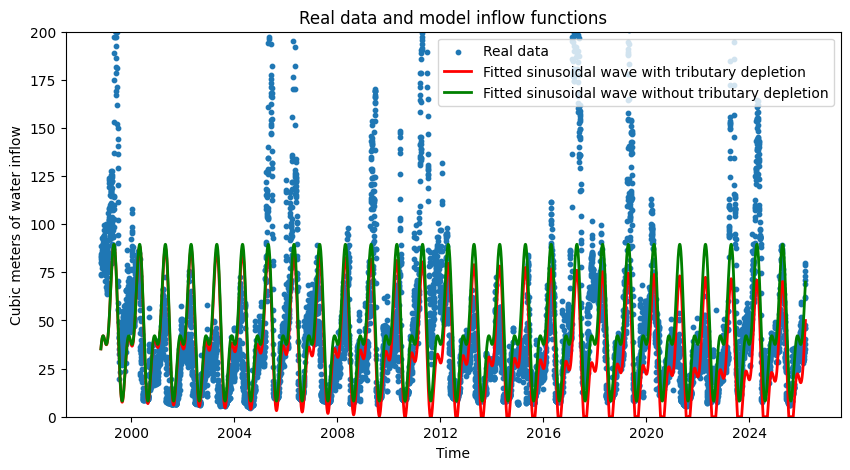

In [10]:
plt.figure(figsize=(10, 5))
plt.scatter(df["time"], df["value"], s=10, label="Real data")
plt.plot(df["time"], np.maximum(df["fit3"], 0), linewidth=2, label="Fitted sinusoidal wave with tributary depletion", c='r')
plt.plot(df["time"], df["fit2"], linewidth=2, label="Fitted sinusoidal wave without tributary depletion", c='green')
plt.title(r"Real data and model inflow functions")
plt.ylim(0, 200)
plt.xlabel("Time")
plt.ylabel("Cubic meters of water inflow")
plt.legend()
plt.savefig('images/inflow.png')
plt.show()

In [143]:
df_2000 = df[df["time"] >= "2000-01-01"].copy()
len(df_2000)

9566

In [144]:
df_2000.set_index(np.arange(9566), inplace=True)

In [145]:
df_2000["day"] = np.mod(np.arange(9566), 365)

In [456]:
df_2000["year"] = 0
for i in range(len(df_2000)):
    df_2000.at[i, "year"] = int(str(df_2000.iloc[i]["time"]).split("-")[0])

In [457]:
def find_a_and_b(mean, var):
    b = mean / var
    a = mean*b
    return a, b

In [164]:
df_2000 = df_2000[['time', 'value', 'day', 'year']]

In [458]:
SPRING_START = 80
SPRING_END = 130
filtered = df_2000[df_2000["day"] >= SPRING_START]
filtered = filtered[filtered["day"] <= SPRING_END]
spring_means = filtered.groupby("year").mean()["value"].values

2.1825133333885867 0.025838829394326426


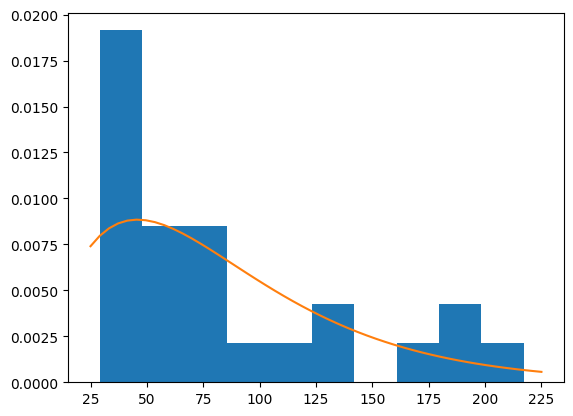

In [459]:
a, b = find_a_and_b(np.mean(spring_means[:-1]), np.var(spring_means[:-1], ddof=1))
domain = np.linspace(25, 225)
plt.hist(spring_means[:-1], density=True, bins=10)
plt.plot(domain, stats.gamma.pdf(domain, a, scale=1/b))
print(a, b)

In [460]:
df_2000 = df_2000[df_2000["year"] <= 2025]
spring_mean_dict = {}
df_2000["spring mean"] = 1
years = np.arange(2000, 2027)
for i in range(26):
    year = years[i]
    spring_mean_dict[year] = spring_means[i]
for i in range(len(df_2000)):
    df_2000.at[i, "spring mean"] = spring_mean_dict[df_2000.iloc[i]["year"]]
df_2000["adj value"] = df_2000["value"] / df_2000["spring mean"]

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_68216/1648123392.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '66.43010233725491' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_2000.at[i, "spring mean"] = spring_mean_dict[df_2000.iloc[i]["year"]]


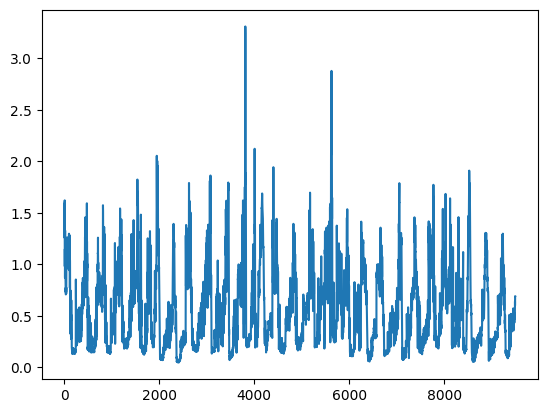

In [461]:
plt.plot(df_2000["adj value"])

In [465]:
day_adj_vals = df_2000.groupby("day").mean()["adj value"].values
day_adj_vars = df_2000[["day", "adj value"]].groupby("day").var()["adj value"].values

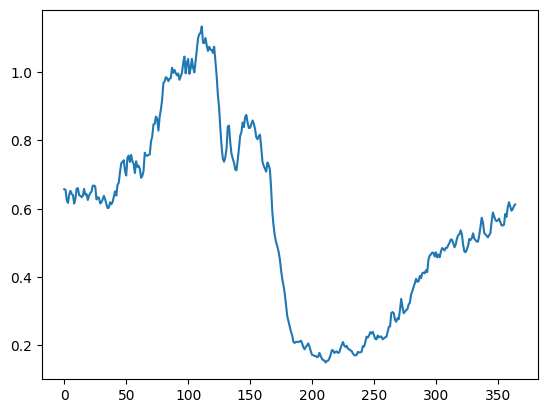

In [253]:
plt.plot(np.arange(365), day_adj_vals)

[ 0.3362724   0.26361918 -0.1660489   0.55571495  0.56250287]


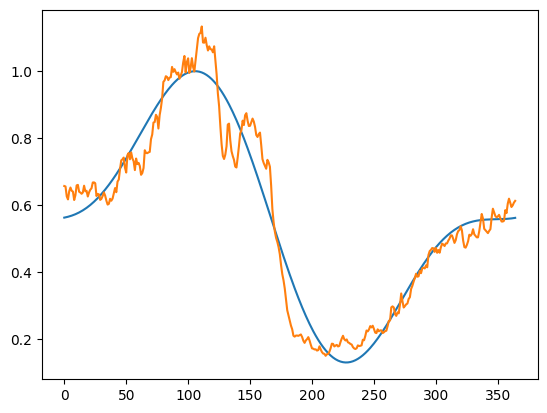

In [464]:
def seasonal_two_harmonics(t, A1, phi1, A2, phi2, C):
    omega = 2 * np.pi / 365
    return (
        A1 * np.sin(omega * t + phi1)
        + A2 * np.sin(2 * omega * t + phi2)
        + C
    )

p0 = [
    (y.max() - y.min()) / 2, 0,
    (y.max() - y.min()) / 4, 0,
    y.mean()
]

params, _ = curve_fit(seasonal_two_harmonics, np.arange(365), day_adj_vals)
print(params)
plt.plot(np.arange(365), seasonal_two_harmonics(np.arange(365), *params))
plt.plot(np.arange(365), day_adj_vals)
plt.show()

In [463]:
df_2000["error"] = 1000
df_2000["pred"] = 0
for i in range(len(df_2000)):
    pred = df_2000.iloc[i]["spring mean"] * day_adj_vals[df_2000.iloc[i]["day"]]
    day = df_2000.iloc[i]["day"]
    pred2 = df_2000.iloc[i]["spring mean"] * seasonal_two_harmonics(day, *params)
    df_2000.at[i, "pred"] = pred
    df_2000.at[i, "pred2"] = pred2
    df_2000.at[i, "error"] = pred - df_2000.iloc[i]["value"]

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_68216/2878143146.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '43.63987391904462' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_2000.at[i, "pred"] = pred
/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_68216/2878143146.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-48.757844480955384' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_2000.at[i, "error"] = pred - df_2000.iloc[i]["value"]


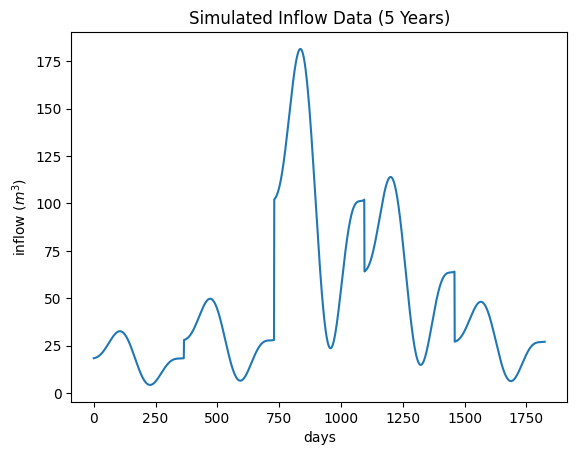

In [467]:
a = 2.1825133333885867 
b = 0.025838829394326426
params = [0.3362724, 0.26361918, -0.1660489, 0.55571495, 0.56250287]
def seasonal_two_harmonics(t, A1, phi1, A2, phi2, C):
    omega = 2 * np.pi / 365
    return (
        A1 * np.sin(omega * t + phi1)
        + A2 * np.sin(2 * omega * t + phi2)
        + C
    )
def simulate(num_years):
    draws = stats.gamma.rvs(a, scale=1/b, size=num_years)
    stretches = np.ravel(np.array([[draw]*365 for draw in draws]))
    return seasonal_two_harmonics(np.array(list(range(365))*num_years), *params)*stretches
num_years = 5
plt.plot(np.arange(365*num_years), simulate(num_years))
plt.title(f"Simulated Inflow Data ({num_years} Years)")
plt.xlabel("days")
plt.ylabel(r"inflow ($m^3$)")
plt.show()

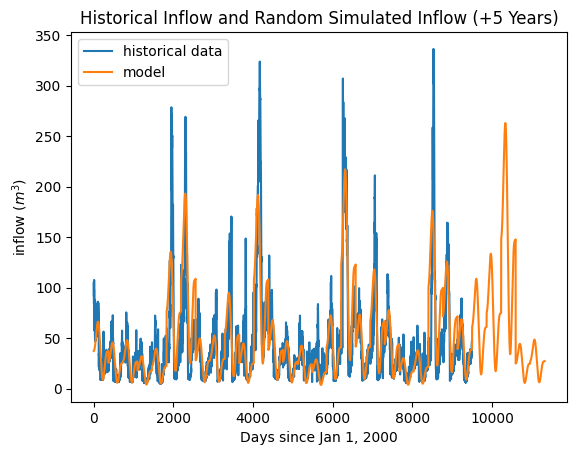

In [ ]:
plt.title("Historical Inflow and Random Simulated Inflow (+5 Years)")
plt.plot(df_2000["value"], label="historical data")
# plt.plot(df_2000["pred"])
plt.plot(list(df_2000["pred2"]) + list(simulate(5)), label="model")
plt.legend()
plt.xlabel("Days since Jan 1, 2000")
plt.ylabel(r"inflow ($m^3$)")
plt.savefig("./images/simulated_5year_inflow_model.png")

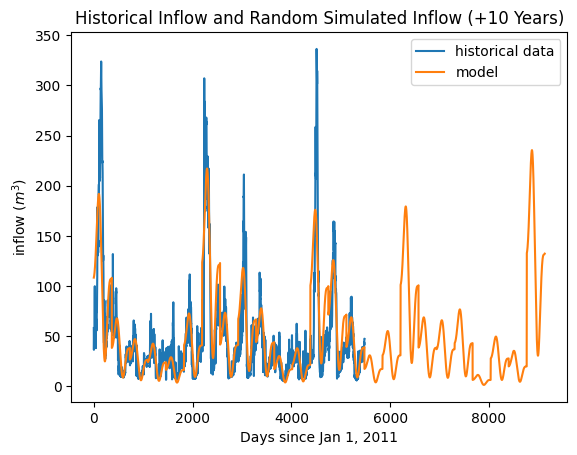

In [470]:
plt.title("Historical Inflow and Random Simulated Inflow (+10 Years)")
plt.plot(np.arange(5479), df_2000["value"][4018:], label="historical data")
# plt.plot(df_2000["pred"])
plt.plot(list(df_2000["pred2"][4018:]) + list(simulate(10)), label="model")
plt.legend()
plt.xlabel("Days since Jan 1, 2011")
plt.ylabel(r"inflow ($m^3$)")
plt.savefig("./images/simulated_10year_inflow_model.png")

In [472]:
df_2000[["time", "value", "pred2"]].to_csv("./data/inflow_model.csv")